In [1]:
# import numpy and pandas library
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
# calculate accuracy measures and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve

# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

import h5py
import tensorflow as tf
import keras

Using TensorFlow backend.


In [0]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
h5FilePath="/content/drive/My Drive/AIML/Deep Learning/SVHN_single_grey1.h5"

In [0]:
#Read SVHN data from h5 file
svhn_h5f = h5py.File(h5FilePath,"r")

In [6]:
#Get Keys from h5py object
keys=svhn_h5f.keys()
for key in keys:
    print(key)

X_test
X_train
X_val
y_test
y_train
y_val


In [0]:
#Get Train, Test and Validation data along with Label
X_train=svhn_h5f['X_train'][:]
y_train=svhn_h5f['y_train'][:]

X_test=svhn_h5f['X_test'][:]
y_test=svhn_h5f['y_test'][:]

X_val=svhn_h5f['X_val'][:]
y_val=svhn_h5f['y_val'][:]

In [8]:
#Get Train Y label unique value
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [9]:
#Get Test Y label unique value
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [10]:
#Get Test Y label unique value
np.unique(y_val)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [0]:
#Close h5 file
svhn_h5f.close()

In [12]:
print("Training Set",X_train.shape, y_train.shape )
print("Validation Set",X_val.shape, y_val.shape )
print("Test Set",X_test.shape, y_test.shape )

Training Set (42000, 32, 32) (42000,)
Validation Set (60000, 32, 32) (60000,)
Test Set (18000, 32, 32) (18000,)


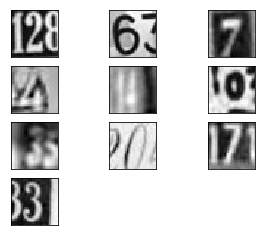

label for each of the above image:
 [2, 6, 7, 4, 4, 0, 3, 0, 7, 3]


In [13]:
# Visualize first 10 train data with label
labels = []

plt.figure(figsize=(5,5))
for i in range(10):
    plt.subplot(5,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray'))
    lbl=y_train[i]
    labels.append(lbl)
plt.show()
print("label for each of the above image:\n", labels)

**Convert train, test and validation data labels to one hot vectors**

In [0]:
num_classes = 10 # No. of unique Label in the dataset (From 1 to 10)
# Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

In [16]:
print(y_train.shape)
print('First 5 examples now are: \n', y_train[0:5])

(42000, 10)
First 5 examples now are: 
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


**Normalize the Train, Test and Validation image data**

In [0]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
X_val = X_val.astype('float32') / 255

# **Reshape the data**

In [0]:
# reshape dataset to have a single channel
X_train = X_train.reshape((X_train.shape[0], 32, 32, 1))
X_test = X_test.reshape((X_test.shape[0], 32, 32, 1))
X_val = X_val.reshape((X_val.shape[0], 32, 32, 1))

In [19]:
print("Training Set",X_train.shape )
print("Validation Set",X_val.shape )
print("Test Set",X_test.shape )

Training Set (42000, 32, 32, 1)
Validation Set (60000, 32, 32, 1)
Test Set (18000, 32, 32, 1)


**Build a model**

In [0]:
#Initialize model1
model1 = tf.keras.models.Sequential()

In [21]:
model1.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 1)))
model1.add(tf.keras.layers.Flatten())
#Add - Dense Layer - 128 Nurons with Relu
model1.add(tf.keras.layers.Dense(128, activation='relu'))
#Add - Dense Layer/output layer - 10 Nurons with Softmax
model1.add(tf.keras.layers.Dense(10, activation='softmax'))

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
# compile model
model1.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
# Fit the model1 with 10 epochs and batch size 32 for train and validation data
m1_history=model1.fit(X_train, y_train, 
          validation_data=(X_val, y_val), 
          epochs=10,
          batch_size=32)

Train on 42000 samples, validate on 60000 samples
Epoch 1/10
42000/42000 [==============================] - 64s 2ms/sample - loss: 2.2455 - acc: 0.1940 - val_loss: 2.0705 - val_acc: 0.2661
Epoch 2/10
42000/42000 [==============================] - 63s 2ms/sample - loss: 1.5848 - acc: 0.5037 - val_loss: 1.3436 - val_acc: 0.5615
Epoch 3/10
42000/42000 [==============================] - 64s 2ms/sample - loss: 1.1931 - acc: 0.6345 - val_loss: 1.1500 - val_acc: 0.6439
Epoch 4/10
42000/42000 [==============================] - 64s 2ms/sample - loss: 1.0717 - acc: 0.6760 - val_loss: 1.0668 - val_acc: 0.6775
Epoch 5/10
42000/42000 [==============================] - 64s 2ms/sample - loss: 0.9941 - acc: 0.6979 - val_loss: 0.9483 - val_acc: 0.7111
Epoch 6/10
42000/42000 [==============================] - 64s 2ms/sample - loss: 0.9309 - acc: 0.7157 - val_loss: 0.8927 - val_acc: 0.7301
Epoch 7/10
42000/42000 [==============================] - 64s 2ms/sample - loss: 0.8812 - acc: 0.7345 - val_loss: 0.

In [24]:
# list all data in history
print(m1_history.history.keys())

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


**Plot Model1 Fit output for Train & Validation Data**

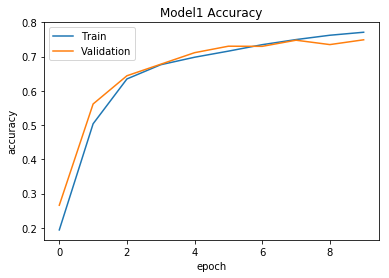

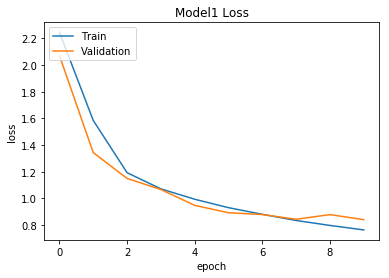

In [25]:
# summarize history for accuracy
plt.plot(m1_history.history['acc'])
plt.plot(m1_history.history['val_acc'])
plt.title('Model1 Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(m1_history.history['loss'])
plt.plot(m1_history.history['val_loss'])
plt.title('Model1 Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()